# Bank Customer Churn Analysis
## Data Preprocessing


In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, f1_score, accuracy_score, roc_curve, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay, average_precision_score
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from metrics import print_binary_classification_metrics

In [2]:
bank = pd.read_csv('./Bank Customer Churn Prediction.csv')
bank.head(5)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [4]:
bank.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [5]:
bank['country'].value_counts()

country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [6]:
## DataFrame에서 X, y 분리
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

cate_item = ['country','gender']
numeric_item = ['customer_id','credit_score','age','tenure','balance','products_number','credit_card','active_member','estimated_salary']

target = ['churn']
cate_index = [2,3]
num_index = [0, 1, 4, 5,6,7,8,9,10]

tscv = TimeSeriesSplit(n_splits=5)


bank['country'] = LabelEncoder().fit_transform(bank['country'])
bank['gender'] = LabelEncoder().fit_transform(bank['gender'])
bank['churn'] = LabelEncoder().fit_transform(bank['churn'])

y = bank['churn']
X = bank.drop(columns='churn')

X.shape, y.shape




((10000, 11), (10000,))

In [152]:
#y = bank['churn'].values.reshape(-1,1)
#X = bank.drop(columns="churn").values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=10,stratify=y)
X_train.shape, X_test.shape



((7500, 11), (2500, 11))

In [168]:
'''
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

# 범주형 컬럼 전처리 파이프라인
cate_preprocessing = Pipeline([("ohe", OneHotEncoder(handle_unknown="ignore"))])

# 수치형 컬럼 전처리 파이프라인
num_preprocessing = Pipeline([("scaler", StandardScaler())])

# ColumnTransformer로 컬럼별로 전처리 파이프라인 정의.
preprocessing = ColumnTransformer([
    ("category", cate_preprocessing, cate_index),
    ("number", num_preprocessing, num_index)
])
# preprocessing
# 전처리기와 모델을 묶는 파이프라인

pipeline = Pipeline([
    ("preprocessor", preprocessing),
    ("model", LogisticRegression(max_iter=2000))
])
'''


In [ ]:
# pipeline.fit(X_train, y_train)

In [ ]:
# print_binary_classification_metrics(y_test,pipeline.predict(X_test), pipeline.predict_proba(X_test)[:, 0], "Pipeline Test set")

### K_fold

In [17]:
'''
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_validate, StratifiedKFold

sf = StratifiedKFold(n_splits=4)
s_gen = sf.split(X, y)
train_idx, valid_idx = next(s_gen)

np.unique(y[train_idx], return_counts=True)
np.unique(y[valid_idx], return_counts=True)

s_kfold = StratifiedKFold(n_splits=4)
s_gen = s_kfold.split(X, y)


max_depth_list = [i for i in range(1,11)]
results = {"max_depth": [], "scores": [], "mean_score": []}


val_result = []
for train_idx, test_idx in s_gen:

    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    print("X type: ", type(X_train))
    # 모델링
    max_depth = 5

    model = DecisionTreeClassifier(max_depth=max_depth, random_state=10)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    val_result.append(accuracy_score(y_test, pred))


print("StratifiedKFold: decision tree validation_result")
print(val_result)
'''


X type:  <class 'numpy.ndarray'>
X type:  <class 'numpy.ndarray'>
X type:  <class 'numpy.ndarray'>
X type:  <class 'numpy.ndarray'>
StratifiedKFold: decision tree validation_result
[0.8492, 0.8596, 0.8536, 0.8496]


## Decision Tree

In [35]:
##### DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=10)


param_tree = { 'max_features': ['sqrt', 'log2'],
               'max_depth': [3, 5, 7],
               'min_samples_split': [2, 5, 8],
               'min_samples_leaf':[1, 2, 4, 8],
               'class_weight': ['balanced']
}

tree_random = RandomizedSearchCV(estimator = tree,
                                param_distributions = param_tree,
                                n_iter = 5,
                                verbose=0,
                                scoring='roc_auc',
                                random_state=10,
                                n_jobs = -1)

tree_random.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,DecisionTreeC...ndom_state=10)
,param_distributions,"{'class_weight': ['balanced'], 'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,5
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,10
,error_score,nan


In [36]:
best_tree = tree_random.best_estimator_
print("Best Parameter (Decision Tree):", tree_random.best_params_)

y_predict_tree = best_tree.predict(X_test)
y_proba_tree = best_tree.predict_proba(X_test)[:, 1]

tree_accuracy = accuracy_score(y_test, y_predict_tree)
tree_f1 = f1_score(y_test, y_predict_tree)
tree_roc_auc = roc_auc_score(y_test, y_proba_tree)
print(f"Accuracy : {tree_accuracy:.6f}")
print(f"F1-score : {tree_f1:.6f}")
print(f"ROC-AUC  : {tree_roc_auc:.6f}")

Best Parameter (Decision Tree): {'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': 7, 'class_weight': 'balanced'}
Accuracy : 0.749200
F1-score : 0.544662
ROC-AUC  : 0.820087


In [37]:
print_binary_classification_metrics(
    y_test, y_predict_tree, y_proba_tree, "Random Forest Prediction"
)

Random Forest Prediction
정확도: 0.7492
재현율: 0.7367387033398821
정밀도: 0.43202764976958524
F1 점수: 0.5446623093681917
Average Precision: 0.6253076123212808
ROC-AUC Score: 0.8200872492029455


In [38]:
print("---------------Decision Tree Test set Classification Report---------------")
print(classification_report(y_test, y_predict_tree))

---------------Decision Tree Test set Classification Report---------------
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1991
           1       0.43      0.74      0.54       509

    accuracy                           0.75      2500
   macro avg       0.67      0.74      0.69      2500
weighted avg       0.82      0.75      0.77      2500



In [39]:
from sklearn.tree import export_graphviz
from graphviz import Source

graph = Source(
    export_graphviz(
        best_tree,
        feature_names=bank.columns[:-1],
        class_names=['Churn', 'Member'],
        filled=True,
        rounded=True
    )
)
graph

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

## Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=10)


param_rf = {'n_estimators': [100, 300, 500, 700, 900],
               'max_features': ['sqrt', 'log2'],
               'max_depth': [3, 5, 7,9],
               'min_samples_split': [2, 5, 8],
               'min_samples_leaf':[1, 2, 4, 8],
               'bootstrap': [True, False],
               'class_weight': ['balanced', 'balanced_subsample']
            }


rf_random = RandomizedSearchCV(estimator = rfc,
                               param_distributions = param_rf,
                               n_iter = 5,
                               scoring='roc_auc',
                               verbose=0,
                               random_state=10,
                               n_jobs = -1)


rf_random.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=10)
,param_distributions,"{'bootstrap': [True, False], 'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2'], ...}"
,n_iter,5
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,10
,error_score,nan


In [42]:
best_random_forest = rf_random.best_estimator_
print("Best Parameter (Random Forest):", rf_random.best_params_)

y_predict_rf = best_random_forest.predict(X_test)
y_proba_rf = best_random_forest.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_predict_rf)
rf_f1 = f1_score(y_test, y_predict_rf)
rf_roc_auc = roc_auc_score(y_test, y_proba_rf)
print(f"Accuracy : {rf_accuracy:.6f}")
print(f"F1-score : {rf_f1:.6f}")
print(f"ROC-AUC  : {rf_roc_auc:.6f}")

Best Parameter (Random Forest): {'n_estimators': 900, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 9, 'class_weight': 'balanced', 'bootstrap': False}
Accuracy : 0.809200
F1-score : 0.601504
ROC-AUC  : 0.858197


In [43]:
print_binary_classification_metrics(
    y_test, y_predict_rf, y_proba_rf, "Random Forest Prediction"
)

Random Forest Prediction
정확도: 0.8092
재현율: 0.7072691552062869
정밀도: 0.5232558139534884
F1 점수: 0.6015037593984962
Average Precision: 0.6821574545186967
ROC-AUC Score: 0.8581968563841806


In [44]:
print(classification_report(y_test, y_predict_rf))

              precision    recall  f1-score   support

           0       0.92      0.84      0.87      1991
           1       0.52      0.71      0.60       509

    accuracy                           0.81      2500
   macro avg       0.72      0.77      0.74      2500
weighted avg       0.84      0.81      0.82      2500



## XGBoost

In [45]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=10, objective='binary:logistic',eval_metric='logloss', tree_method='approx', verbosity=0)


param_xgb = {'n_estimators': [200, 300, 500],
               'booster':['gbtree','gblinear'],
               'learning_rate': [0.01, 0.5, 0.1],
               'max_depth': [3, 5, 7],
               'colsample_bytree': [0.5, 0.6, 0.7],
               "gamma"       : [1, 2, 3]
}

xgbc = RandomizedSearchCV(estimator = xgb,
                    param_distributions = param_xgb,
                   n_iter = 5,
                   verbose=0,
                   random_state=10,
                   n_jobs = -1)


xgbc.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [23:22:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "colsample_bytree", "gamma", "max_depth", "tree_method" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [23:22:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "colsample_bytree", "gamma", "max_depth", "tree_method" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [23:22:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "colsample_bytree", "gamma", "max_depth", "tree_method" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Pytho

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'booster': ['gbtree', 'gblinear'], 'colsample_bytree': [0.5, 0.6, ...], 'gamma': [1, 2, ...], 'learning_rate': [0.01, 0.5, ...], ...}"
,n_iter,5
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,10
,error_score,nan


In [46]:
best_xgb = xgbc.best_estimator_
print("Best parameters (XGBoost):", best_xgb)

y_predict_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, y_predict_xgb)
xgb_f1 = f1_score(y_test, y_predict_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_proba_xgb)
print(f"Accuracy : {xgb_accuracy:.6f}")
print(f"F1-score : {xgb_f1:.6f}")
print(f"ROC-AUC  : {xgb_roc_auc:.6f}")


Best parameters (XGBoost): XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)
Accuracy : 0.863200
F1-score : 0.567089
ROC-AUC  : 0.863003


In [47]:
print_binary_classification_metrics(
    y_test, y_predict_xgb, y_proba_xgb, "XGBoost Results"
)

XGBoost Results
정확도: 0.8632
재현율: 0.4400785854616896
정밀도: 0.797153024911032
F1 점수: 0.5670886075949367
Average Precision: 0.7097363494290012
ROC-AUC Score: 0.8630033579398058


In [48]:
pd.Series(best_xgb.feature_importances_).sort_values(ascending=False)

7     0.286624
4     0.211203
9     0.200196
2     0.068464
6     0.050234
3     0.048419
1     0.028407
8     0.028337
0     0.026959
10    0.025801
5     0.025356
dtype: float32

<Figure size 1000x800 with 0 Axes>

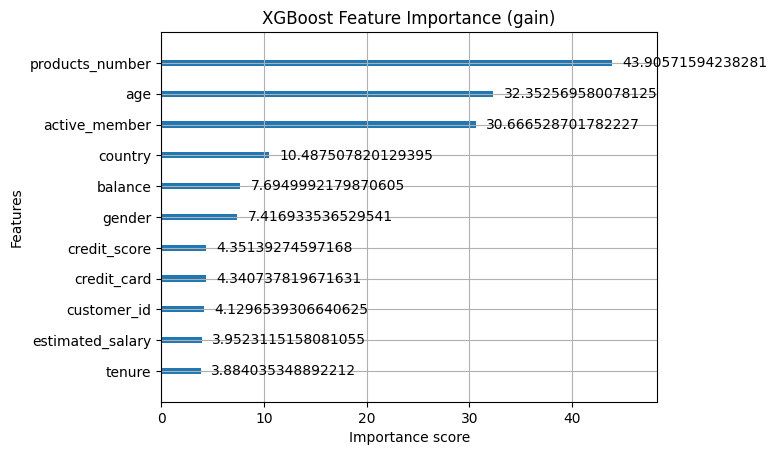

In [68]:
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(best_xgb, importance_type='gain', max_num_features=30)
plt.title("XGBoost Feature Importance (gain)")
plt.show()

## Light GBM

In [52]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(random_state=10, objective='binary',eval_metric='logloss', tree_method='approx', verbosity=-1)

param_lgbm = {'n_estimators': [300, 500, 700],
            'boosting type':['gbtree','gblinear'],
            'learning_rate': [0.01, 0.5, 0.1],
            'max_depth': [5, 7,9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'subsample': [0.6, 0.8, 1.0],
            'feature_fraction': [0.5,0.6,0.7],
            'bagging_fraction': [0.5,0.6,0.7]
}


lgbm_cv = RandomizedSearchCV(estimator = lgbm,
                    param_distributions = param_lgbm,
                   n_iter = 5,
                   verbose=0,
                   random_state=10,
                   n_jobs = -1)



lgbm_cv.fit(X_train, y_train)

,estimator,LGBMClassifie... verbosity=-1)
,param_distributions,"{'bagging_fraction': [0.5, 0.6, ...], 'boosting type': ['gbtree', 'gblinear'], 'colsample_bytree': [0.5, 0.7, ...], 'feature_fraction': [0.5, 0.6, ...], ...}"
,n_iter,5
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,10
,error_score,nan


In [53]:
best_lgbm = lgbm_cv.best_estimator_
print("Best parameters (Light BGM):", best_lgbm)

y_predict_lgbm = best_lgbm.predict(X_test)
y_proba_lgbm = best_lgbm.predict_proba(X_test)[:, 1]

lgbm_accuracy = accuracy_score(y_test, y_predict_lgbm)
lgbm_f1 = f1_score(y_test, y_predict_lgbm)
lgbm_roc_auc = roc_auc_score(y_test, y_proba_lgbm)
print(f"Accuracy : {lgbm_accuracy:.6f}")
print(f"F1-score : {lgbm_f1:.6f}")
print(f"ROC-AUC  : {lgbm_roc_auc:.6f}")

Best parameters (Light BGM): LGBMClassifier(bagging_fraction=0.5, boosting type='gblinear',
               colsample_bytree=0.9, eval_metric='logloss',
               feature_fraction=0.5, max_depth=9, n_estimators=300,
               objective='binary', random_state=10, tree_method='approx',
               verbosity=-1)
Accuracy : 0.860000
F1-score : 0.579327
ROC-AUC  : 0.848040


In [54]:
print_binary_classification_metrics(
    y_test, y_predict_lgbm, y_proba_lgbm, "Light GBM Results"
)

Light GBM Results
정확도: 0.86
재현율: 0.47347740667976423
정밀도: 0.7461300309597523
F1 점수: 0.5793269230769231
Average Precision: 0.6855014691260484
ROC-AUC Score: 0.8480401492373835


In [55]:
pd.Series(best_lgbm.feature_importances_).sort_values(ascending=False)

10    1610
1     1552
0     1454
6     1286
4     1129
5      738
2      331
7      296
9      220
3      207
8      149
dtype: int32

<Figure size 1000x800 with 0 Axes>

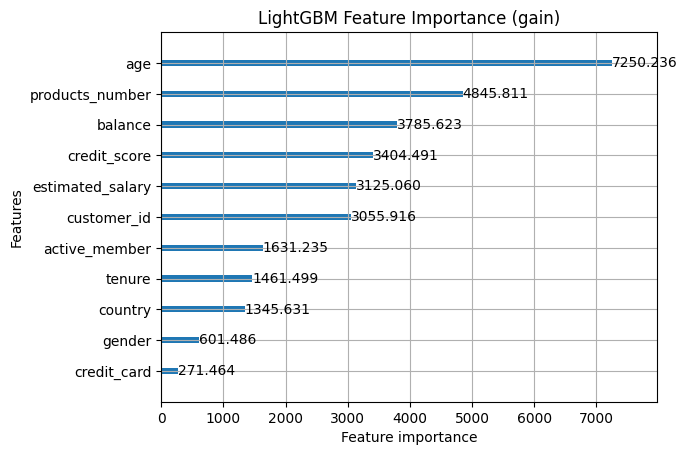

In [71]:
import lightgbm as lgb

plt.figure(figsize=(10, 8))
lgb.plot_importance(best_lgbm, importance_type='gain', max_num_features=30)
plt.title("LightGBM Feature Importance (gain)")
plt.show()

## CatBoost

In [57]:
from catboost import CatBoostClassifier
cat = CatBoostClassifier(random_state=10, eval_metric='AUC', loss_function='Logloss',verbose=False)


param_cat = {'n_estimators': [200,400,600],'learning_rate': [0.05, 0.1], 'depth': [5, 7, 9]}

cat_cv = RandomizedSearchCV(estimator = cat,
                   param_distributions = param_cat,
                   scoring='roc_auc',
                   n_iter = 5,
                   random_state=10,
                   n_jobs = -1
)


cat_cv.fit(X_train, y_train)

,estimator,<catboost.cor...t 0x1186f7b90>
,param_distributions,"{'depth': [5, 7, ...], 'learning_rate': [0.05, 0.1], 'n_estimators': [200, 400, ...]}"
,n_iter,5
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,10
,error_score,nan


In [58]:
best_cat = cat_cv.best_estimator_
print("Best parameters (Cat Boost):", best_cat)

y_predict_cat = best_cat.predict(X_test)
y_proba_cat = best_cat.predict_proba(X_test)[:, 1]

cat_accuracy = accuracy_score(y_test, y_predict_cat)
cat_f1 = f1_score(y_test, y_predict_cat)
cat_roc_auc = roc_auc_score(y_test, y_proba_cat)
print(f"Accuracy : {cat_accuracy:.6f}")
print(f"F1-score : {cat_f1:.6f}")
print(f"ROC-AUC  : {cat_roc_auc:.6f}")

Best parameters (Cat Boost): <catboost.core.CatBoostClassifier object at 0x1186f7e90>
Accuracy : 0.862000
F1-score : 0.577723
ROC-AUC  : 0.868038


In [59]:
print_binary_classification_metrics(
    y_test, y_predict_cat, y_proba_cat, "Cat Boost Results"
)

Cat Boost Results
정확도: 0.862
재현율: 0.4636542239685658
정밀도: 0.7662337662337663
F1 점수: 0.5777233782129743
Average Precision: 0.7163475211003277
ROC-AUC Score: 0.8680378007517127


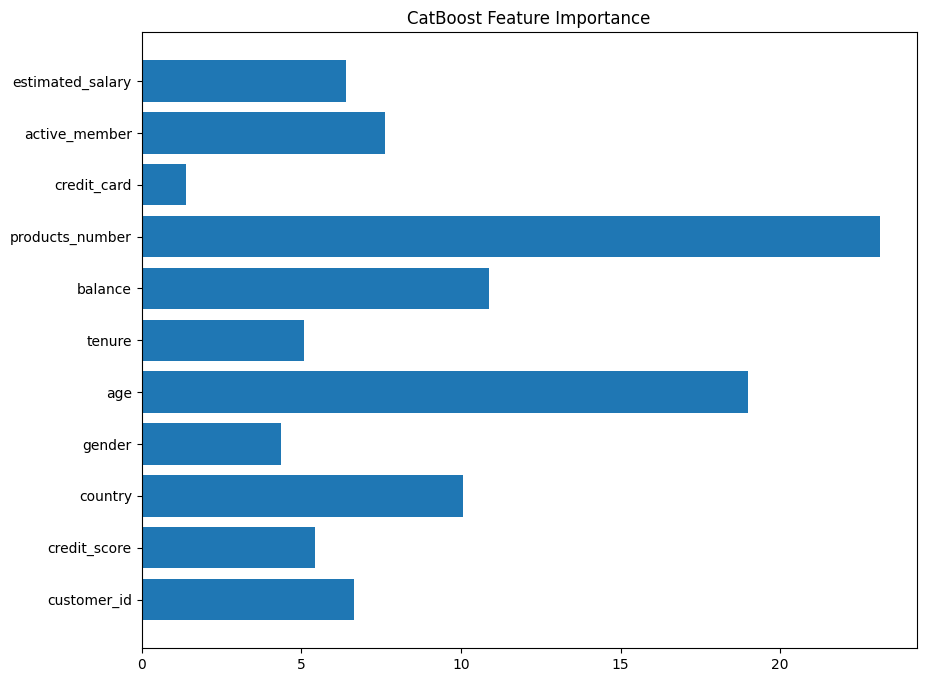

In [69]:
from catboost import Pool

feature_importances = best_cat.get_feature_importance(
    type='PredictionValuesChange'
)
feature_names = best_cat.feature_names_

plt.figure(figsize=(10, 8))
plt.barh(feature_names, feature_importances)
plt.title("CatBoost Feature Importance")
plt.show()

## Optuna

In [62]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):

    classifier_name = trial.suggest_categorical('classifier', ['XGBoost', 'CatBoost', 'LightGBM'])

    if classifier_name == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 700),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.1),
            'random_state': 10
        }
        classifier_obj = XGBClassifier(**params)


    elif classifier_name == 'CatBoost':
        params = {
            'iterations': trial.suggest_int('iterations', 200, 600),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.1),
            'depth': trial.suggest_int('depth', 3, 8),
            'random_state': 10,
            'verbose': False
        }
        classifier_obj = CatBoostClassifier(**params)


    elif classifier_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 700),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.1),
            'random_state': 10,
            'verbose': -1
        }
        classifier_obj = LGBMClassifier(**params)

    accuracy = cross_val_score(classifier_obj, X_train, y_train, scoring='f1').mean()

    return accuracy


In [63]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print("Best Score:", study.best_value)
print("Best Params:", study.best_params)
print("Best Model:", study.best_params['classifier'])

[I 2025-11-24 23:32:33,023] A new study created in memory with name: no-name-ab237f63-6c74-481e-a96d-d984a52aa68a
[I 2025-11-24 23:32:35,329] Trial 0 finished with value: 0.5694654838488452 and parameters: {'classifier': 'CatBoost', 'iterations': 245, 'learning_rate': 0.09310567155359561, 'depth': 8}. Best is trial 0 with value: 0.5694654838488452.
[I 2025-11-24 23:32:38,972] Trial 1 finished with value: 0.5683142902893885 and parameters: {'classifier': 'CatBoost', 'iterations': 538, 'learning_rate': 0.08440947839960479, 'depth': 7}. Best is trial 0 with value: 0.5694654838488452.
[I 2025-11-24 23:32:40,563] Trial 2 finished with value: 0.5653304424376799 and parameters: {'classifier': 'LightGBM', 'n_estimators': 659, 'max_depth': 7, 'learning_rate': 0.08835256769929808}. Best is trial 0 with value: 0.5694654838488452.
[I 2025-11-24 23:32:40,953] Trial 3 finished with value: 0.5802423809644595 and parameters: {'classifier': 'XGBoost', 'n_estimators': 253, 'max_depth': 3, 'learning_rate

Best Score: 0.5875294465899411
Best Params: {'classifier': 'CatBoost', 'iterations': 259, 'learning_rate': 0.05858482243440948, 'depth': 6}
Best Model: CatBoost


### Feature Importance

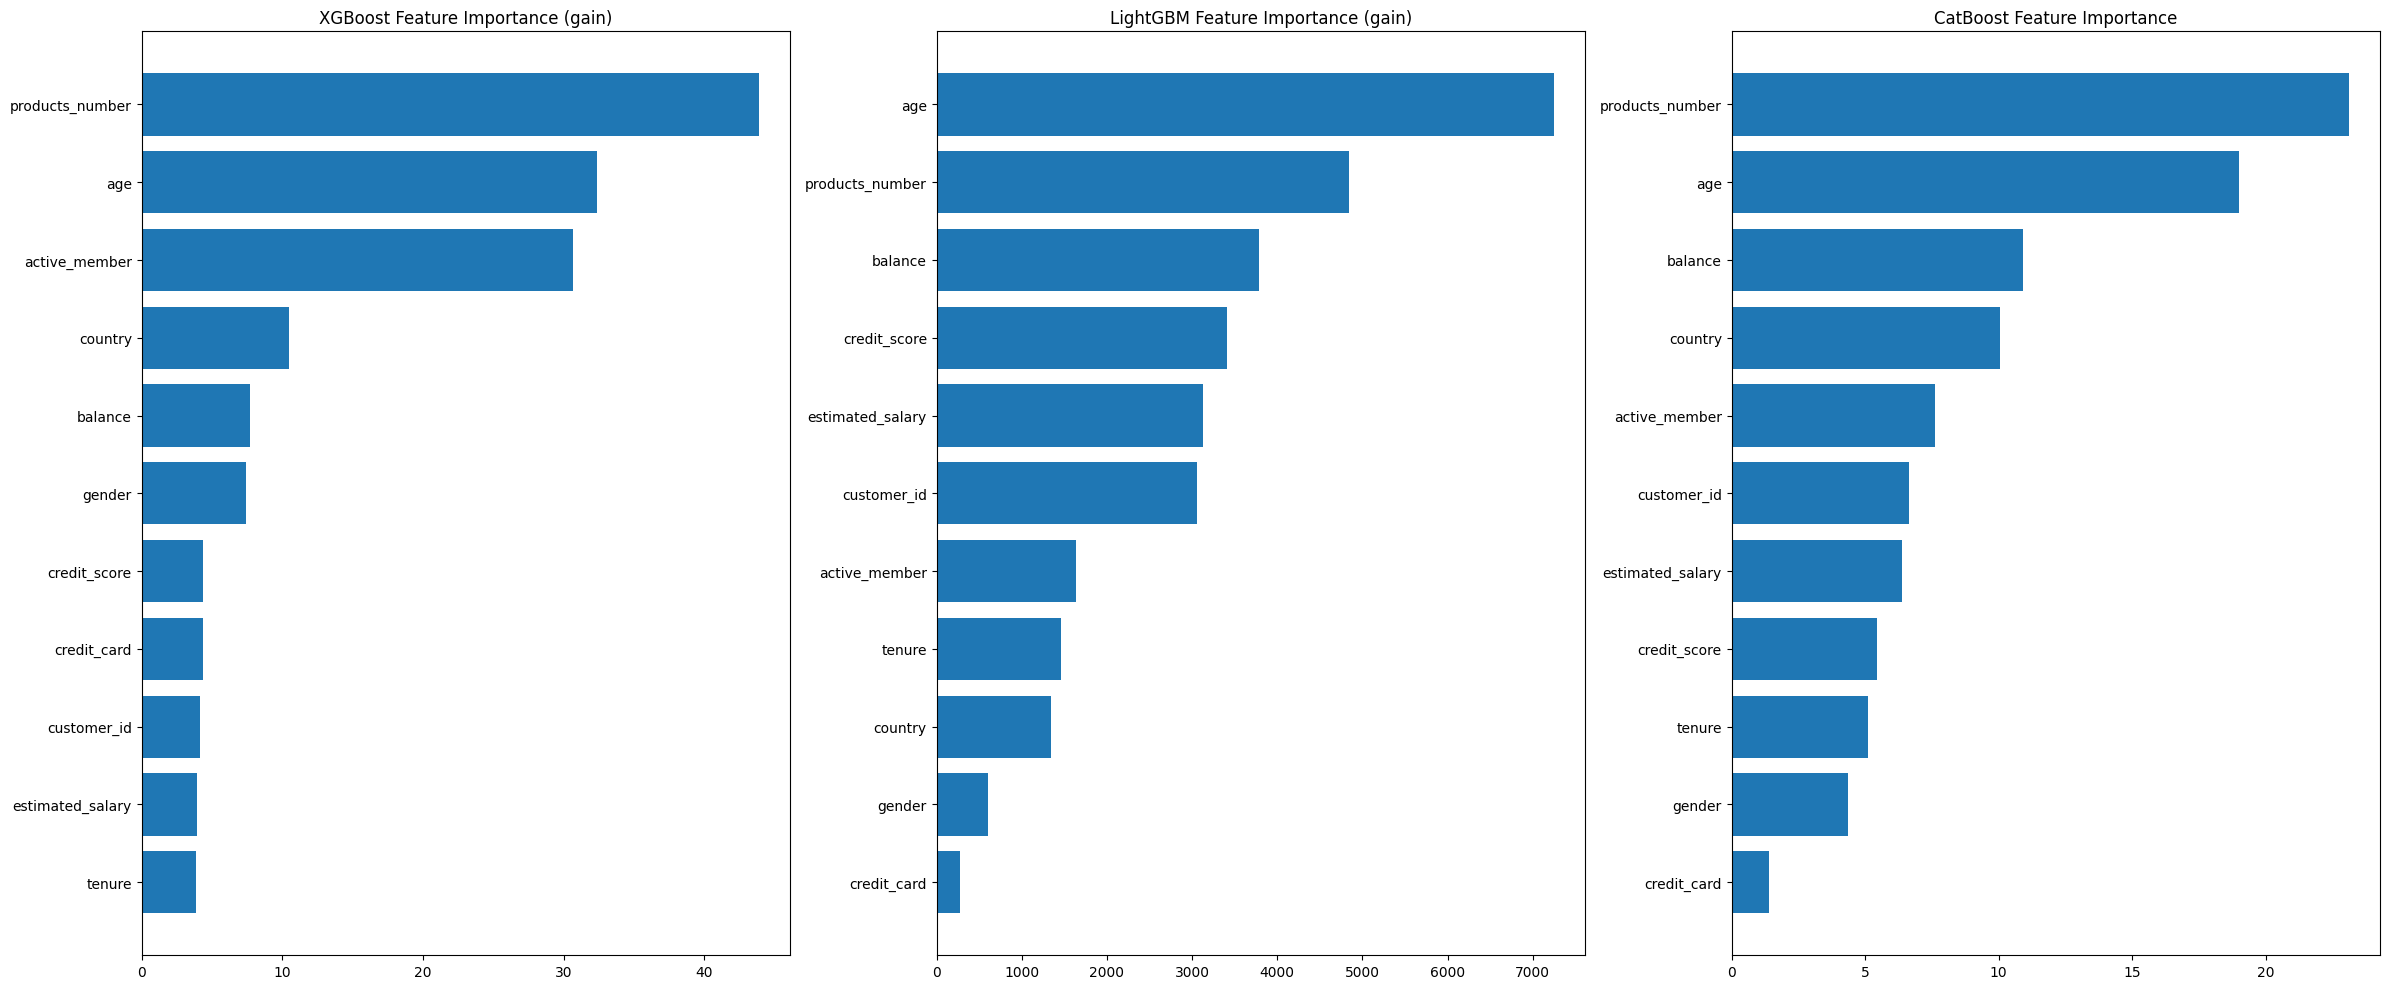

In [74]:
def get_xgb_importance(model, columns):
    booster = model.get_booster()
    importance_dict = booster.get_score(importance_type='gain')
    df = pd.DataFrame({
        'feature': list(importance_dict.keys()),
        'importance': list(importance_dict.values())
    })
    return df.sort_values('importance', ascending=False)

def get_lgb_importance(model, columns):
    importance = model.booster_.feature_importance(importance_type='gain')
    df = pd.DataFrame({
        'feature': columns,
        'importance': importance
    })
    return df.sort_values('importance', ascending=False)

def get_cat_importance(model):
    importance = model.get_feature_importance(type='PredictionValuesChange')
    df = pd.DataFrame({
        'feature': model.feature_names_,
        'importance': importance
    })
    return df.sort_values('importance', ascending=False)

# --- 데이터 준비 ---
xgb_imp = get_xgb_importance(best_xgb, X_train.columns).head(20)
lgb_imp = get_lgb_importance(best_lgbm, X_train.columns).head(20)
cat_imp = get_cat_importance(best_cat).head(20)

# --- 그래프 출력 ---
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

# XGB
axes[0].barh(xgb_imp['feature'], xgb_imp['importance'])
axes[0].set_title("XGBoost Feature Importance (gain)")
axes[0].invert_yaxis()

# LightGBM
axes[1].barh(lgb_imp['feature'], lgb_imp['importance'])
axes[1].set_title("LightGBM Feature Importance (gain)")
axes[1].invert_yaxis()

# CatBoost
axes[2].barh(cat_imp['feature'], cat_imp['importance'])
axes[2].set_title("CatBoost Feature Importance")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

### SHAP Value
SHAP (SHapley Additive exPlanations): “각 feature가 예측에 얼마나 기여했는지”를 게임이론(Shapley Value) 기반으로 계산하는 기법. 모델이 어떤 feature 때문에 값을 예측했는지 각 샘플마다 feature 별로 기여도를 산출함. Tree 기반의 XGBoost, Light GBM, CatBoost와 잘 상응하는 경향이 있음


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


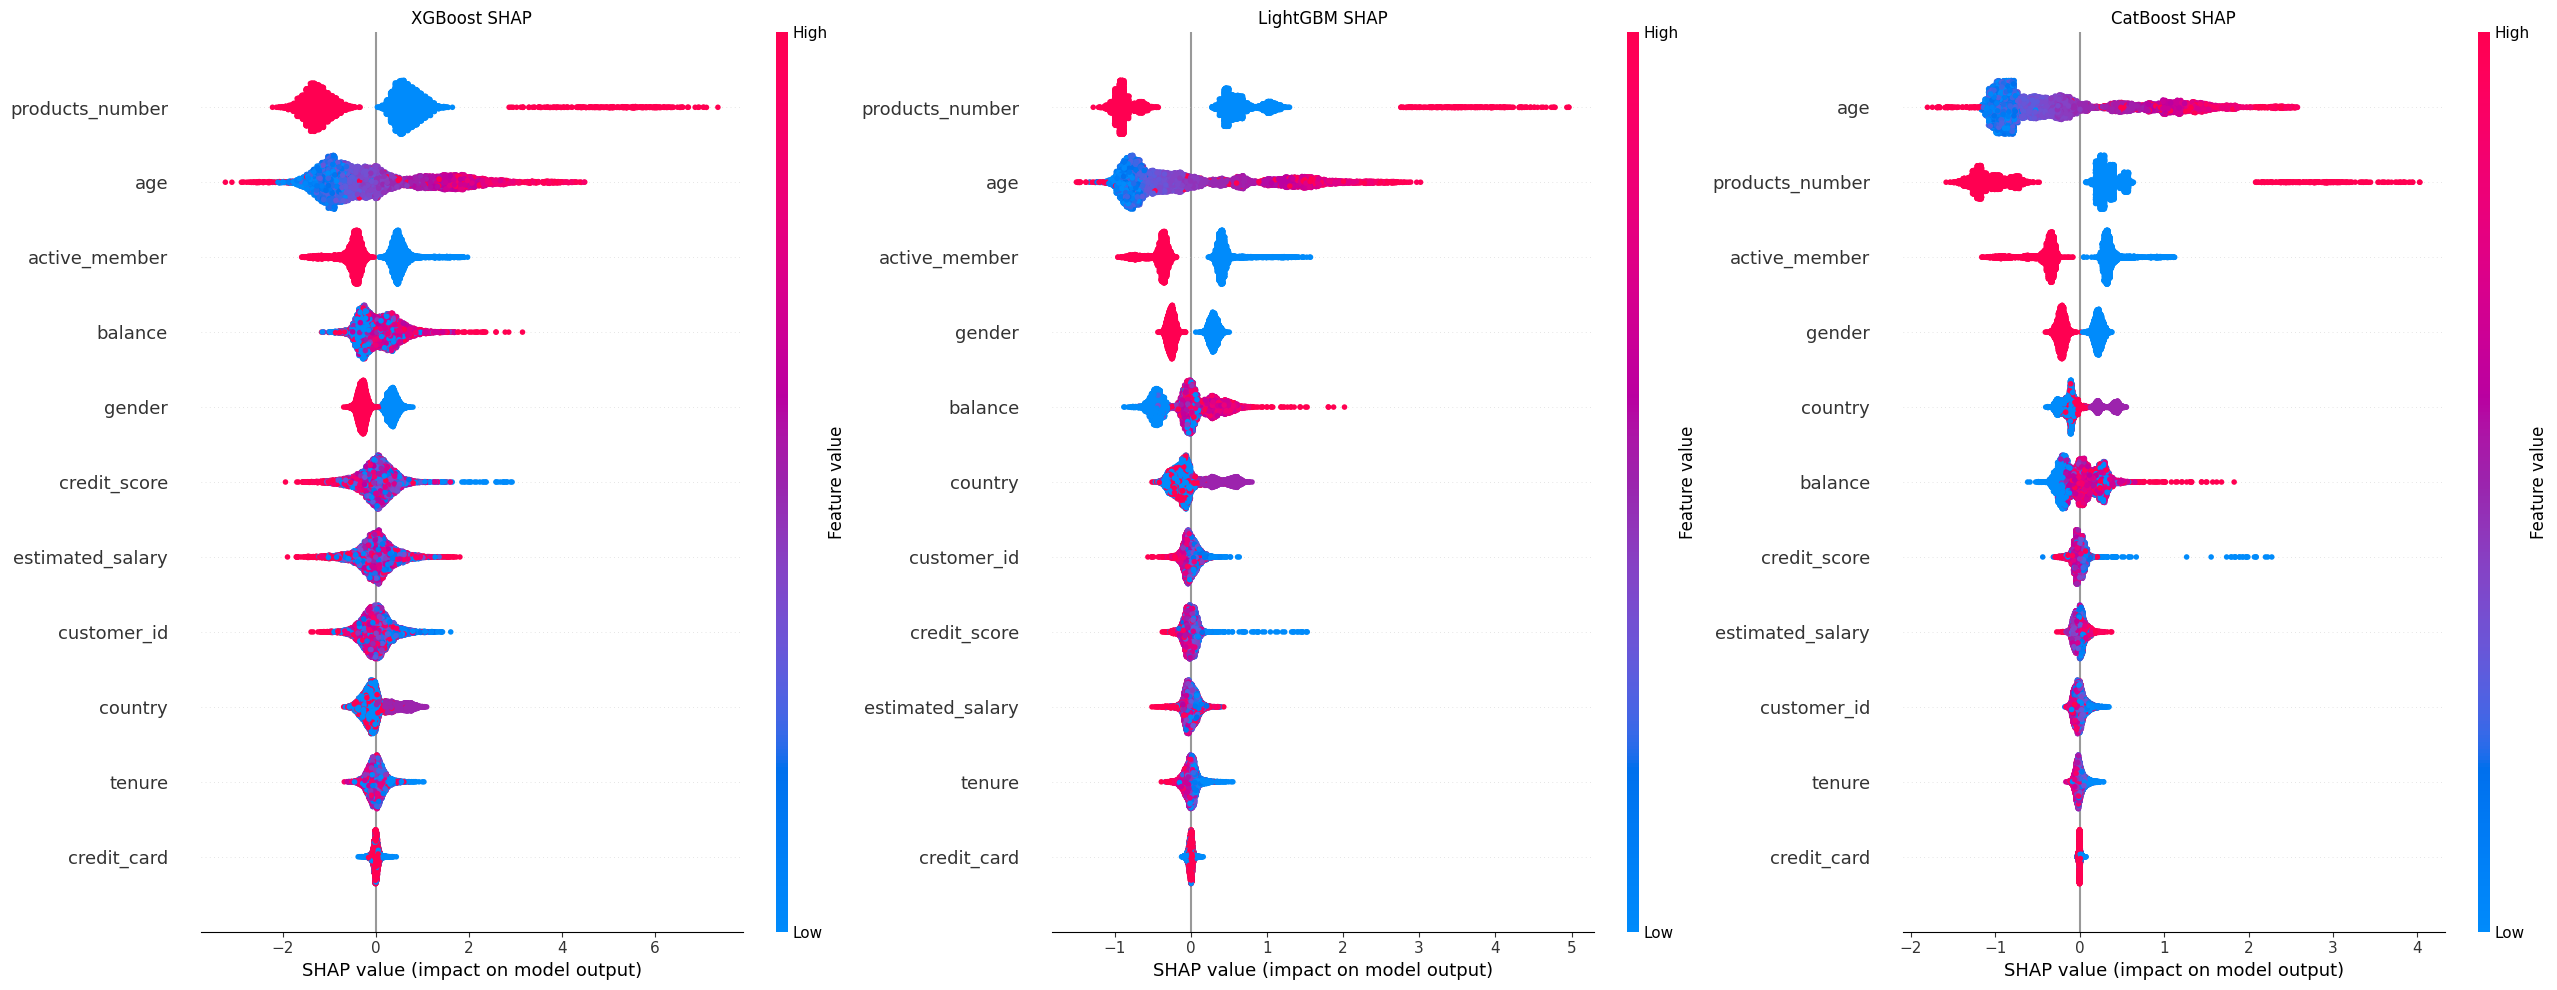

In [75]:
import shap

shap.initjs()

xgb_exp = shap.TreeExplainer(best_xgb)
lgbm_exp = shap.TreeExplainer(best_lgbm)
cat_exp = shap.TreeExplainer(best_cat)

shap_xgb = xgb_exp.shap_values(X_train)
shap_lgbm = lgbm_exp.shap_values(X_train)
shap_cat = cat_exp.shap_values(X_train)

fig, axes = plt.subplots(1, 3, figsize=(26, 10))
shap.summary_plot(shap_xgb, X_train, show=False, plot_size=None)
plt.sca(axes[0])
axes[0].set_title("XGBoost SHAP")
shap.summary_plot(shap_lgbm, X_train, show=False, plot_size=None)
plt.sca(axes[1])
axes[1].set_title("LightGBM SHAP")
shap.summary_plot(shap_cat, X_train, show=False, plot_size=None)
plt.sca(axes[2])
axes[2].set_title("CatBoost SHAP")

plt.tight_layout()
plt.show()

### Precision Recall Curve + AP Score

DecisionTree Average Precision Score: 0.37189149049822096
RandomForest Average Precision Score: 0.42968269749166177
XGBoost Average Precision Score: 0.464809975599354
Light GBM Precision Score: 0.4604757121047157
CatBoost Precision Score: 0.4644675222616284


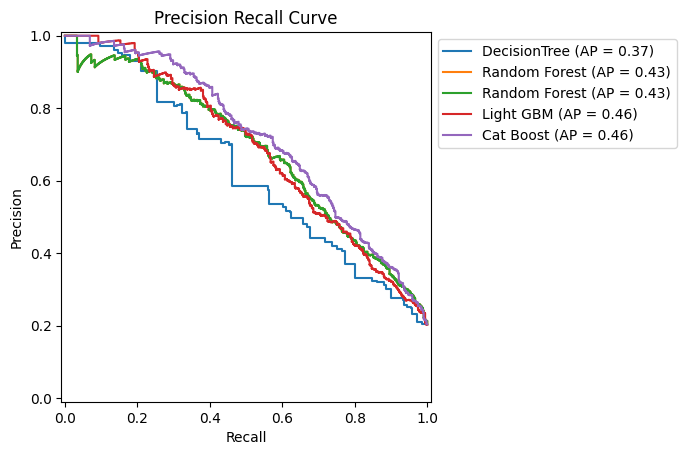

In [64]:
##### DecisionTree의 PrecisionRecall 커브 그리기 + AP Score 계산.
tree_ap = average_precision_score(y_test, y_predict_tree)  # (y정답, 모델이 예측한 이탈한 확률)
rfc_ap = average_precision_score(y_test, y_predict_rf)
xgb_ap = average_precision_score(y_test, y_predict_xgb)
lgbm_ap = average_precision_score(y_test, y_predict_lgbm)
cat_ap = average_precision_score(y_test, y_predict_cat)

print("DecisionTree Average Precision Score:", tree_ap)
print("RandomForest Average Precision Score:", rfc_ap)
print("XGBoost Average Precision Score:", xgb_ap)
print("Light GBM Precision Score:", lgbm_ap)
print("CatBoost Precision Score:", cat_ap)


precisions1, recalls1, _ = precision_recall_curve(y_test, y_proba_tree)
precisions2, recalls2, _ = precision_recall_curve(y_test, y_proba_rf)
precisions3, recalls3, _ = precision_recall_curve(y_test, y_proba_xgb)
precisions4, recalls4, _ = precision_recall_curve(y_test, y_proba_lgbm)
precisions5, recalls5, _ = precision_recall_curve(y_test, y_proba_cat)
ax = plt.gca()

disp_tree = PrecisionRecallDisplay(precisions1, recalls1,  average_precision=tree_ap, estimator_name="DecisionTree" )
disp_tree.plot(ax=ax)

disp_rfc = PrecisionRecallDisplay(precisions2, recalls2, average_precision=rfc_ap, estimator_name="Random Forest")
disp_rfc.plot(ax=ax)

disp_xgb = PrecisionRecallDisplay(precisions3, recalls3, average_precision=xgb_ap, estimator_name="XGBoost")
disp_rfc.plot(ax=ax)

disp_lgbm = PrecisionRecallDisplay(precisions4, recalls4, average_precision=lgbm_ap, estimator_name="Light GBM")
disp_lgbm.plot(ax=ax)

disp_cat = PrecisionRecallDisplay(precisions5, recalls5, average_precision=cat_ap, estimator_name="Cat Boost")
disp_cat.plot(ax=ax)

plt.title("Precision Recall Curve")
plt.legend(bbox_to_anchor=(1,1), loc="upper left")
plt.show()

ROC-AUC Curve


In [65]:
fpr1, recall1, thresh1 = roc_curve(y_test, y_proba_tree)
fpr2, recall2, thresh2 = roc_curve(y_test, y_proba_rf)
fpr3, recall3, thresh3 = roc_curve(y_test, y_proba_xgb)
fpr4, recall4, thresh4 = roc_curve(y_test, y_proba_lgbm)
fpr5, recall5, thresh5 = roc_curve(y_test, y_proba_cat)

pd.DataFrame({"Thresh": thresh1,"FPR":fpr1,"Recall":recall1})

,Thresh,FPR,Recall
0,inf,0.000000,0.000000
1,1.000000,0.000502,0.098232
2,0.992638,0.001005,0.135560
3,0.978235,0.001507,0.147348
4,0.972357,0.002009,0.157171
5,0.969009,0.002511,0.163065
6,0.964737,0.002511,0.178782
7,0.964245,0.004018,0.210216
8,0.944247,0.007032,0.255403
9,0.876745,0.017077,0.300589


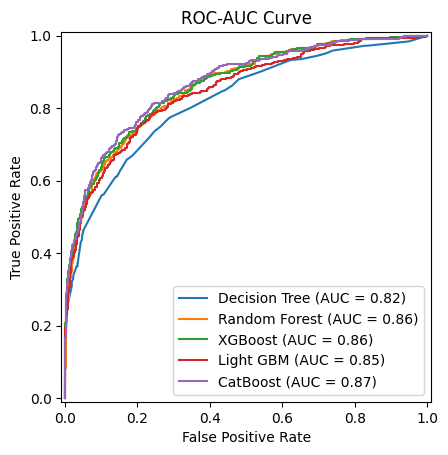

In [66]:
ax = plt.gca()
ax.set_title("ROC-AUC Curve")

disp_roc_tree = RocCurveDisplay(
    fpr=fpr1, tpr=recall1,
    roc_auc=tree_roc_auc,
    name="Decision Tree"
)
disp_roc_tree.plot(ax=ax)

disp_roc_rfc = RocCurveDisplay(
    fpr=fpr2, tpr=recall2,
    roc_auc=rf_roc_auc,
    name="Random Forest"
)
disp_roc_rfc.plot(ax=ax)

disp_roc_xgb = RocCurveDisplay(
    fpr=fpr3, tpr=recall3,
    roc_auc=xgb_roc_auc,
    name="XGBoost"
)
disp_roc_xgb.plot(ax=ax)

disp_roc_lgbm = RocCurveDisplay(
    fpr=fpr4, tpr=recall4,
    roc_auc=lgbm_roc_auc,
    name="Light GBM"
)
disp_roc_lgbm.plot(ax=ax)

disp_roc_cat = RocCurveDisplay(
    fpr=fpr5, tpr=recall5,
    roc_auc=cat_roc_auc,
    name="CatBoost"
)
disp_roc_cat.plot(ax=ax)


plt.show()

### Final

In [67]:
results = [{
        "Model": "Decision Tree",
        "F1-score": f'{tree_f1:.6f}',
        "Accuracy": f'{tree_accuracy:.6f}',
        "ROC-AUC": f'{tree_roc_auc:.6f}',
        "Hyper param": f'{tree_random.best_params_}'
},{
        "Model": "RandomForest",
        "F1-score": f'{rf_f1:.6f}',
        "Accuracy": f'{rf_accuracy:.6f}',
        "ROC-AUC": f'{rf_roc_auc:.6f}',
        "Hyper param": f'{rf_random.best_params_}'
},{
        "Model": "XGBoost",
        "F1-score": f'{xgb_f1:.6f}',
        "Accuracy": f'{xgb_accuracy:.6f}',
        "ROC-AUC": f'{xgb_roc_auc:.6f}',
        "Hyper param": f'{best_xgb}'
},{
        "Model": "LightGBM",
        "F1-score": f'{lgbm_f1:.6f}',
        "Accuracy": f'{lgbm_accuracy:.6f}',
        "ROC-AUC": f'{lgbm_roc_auc:.6f}',
        "Hyper param": f'{best_lgbm}'
},{
        "Model": "CatBoost",
        "F1-score": f'{cat_f1:.6f}',
        "Accuracy": f'{cat_accuracy:.6f}',
        "ROC-AUC": f'{cat_roc_auc:.6f}',
        "Hyper param": f'{best_cat}'
}]
df_results = pd.DataFrame(results)
df_results

,Model,F1-score,Accuracy,ROC-AUC,Hyper param
0,Decision Tree,0.544662,0.749200,0.820087,"{'min_samples_split': 2, 'min_samples_leaf': 8..."
1,RandomForest,0.601504,0.809200,0.858197,"{'n_estimators': 900, 'min_samples_split': 5, ..."
2,XGBoost,0.567089,0.863200,0.863003,"XGBClassifier(base_score=None, booster='gbtree..."
3,LightGBM,0.579327,0.860000,0.848040,"LGBMClassifier(bagging_fraction=0.5, boosting ..."
4,CatBoost,0.577723,0.862000,0.868038,<catboost.core.CatBoostClassifier object at 0x...


## 다층 퍼셉트론 Fully Connected Neural Network

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
import numpy as np

# X, y 는 기존 데이터 그대로 사용
# (이미 LabelEncoder로 처리한 상태라고 가정)


# ----- 2) Scaling -----
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.astype(float))
X_test = scaler.transform(X_test.astype(float))

# ----- 3) Class Weight (불균형 데이터용) -----
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(weights))


# ----- 4) Neural Network Model -----
def build_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
        layers.Dropout(0.2),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['AUC', 'accuracy']
    )
    return model


model = build_model(X_train.shape[1])
model.summary()

# ----- 5) Train -----
early = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=5,
    mode='max',
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early],
    verbose=2
)

# ----- 6) Evaluate -----
model.evaluate(X_test, y_test, verbose=2)